# Importation des modules

In [ ]:
!pip install openpyxl
!pip install missingno
!pip install statsmodels


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 7.7 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 9.0 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 9.2 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 9.3 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 9.4 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   --------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import os
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Chargement des données
diviser les dépenses de santé par le PIB pour les avoir en %  
rajouter les données de dépenses de santé pour 1994 - 2004 en regardant sur les données de l'ocde  
rajouter la base mortalite  
faire le tri dans les pays de la bdd nb de médecins  


In [2]:
depenses_sante_vol = pd.read_excel(os.path.join("data", "Depenses_sante_en_volume_fr.xlsx"))
depenses_sante_PIB = pd.read_excel(os.path.join("data", "Depenses_Sante_PIB_OCDE_fr.xlsx"))
pib = pd.read_excel(os.path.join("data", "PIB_fr.xlsx"))
pib_par_habitant = pd.read_excel(os.path.join("data", "PIB_par_habitant_fr.xlsx"))
pop_tot = pd.read_excel(os.path.join("data", "Pop_tot_fr.xlsx"))
pop65 = pd.read_excel(os.path.join("data", "Pop+65ans_fr.xlsx"))
part_pop65 = pd.read_excel(os.path.join("data", "part_pop_plus_65_fr.xlsx"))
pop_par_age = pd.read_excel(os.path.join("data", "Population_par_age_tranches5ans_fr.xlsx"))
offre_medicale = pd.read_excel(os.path.join("data", "Offre-medicale_Practiciens.xlsx"))

In [3]:
offre_medicale

,TIME,1993,1994,1995,1996,1997,1998,1999,2000,2001,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Belgique,:,:,:,:,:,:,:,107.03,107.4,...,110.8,112.86,113.41,115.04,116.85,118.71,120.42,120.21,123.56,:
1,Tchéquie,:,:,67.37,:,:,:,:,70.1,:,...,:,:,:,:,68.69,67.13,71.82,77.19,76.37,:
2,Danemark,:,43.21,47.3,49.21,55.3,58.92,60.33,67.93,68.38,...,78.8,78.97,79.52,80.07,79.82,79.53,80.15,71.81,68.93,:
3,Allemagne,75.65,77.82,79.76,81.2,81.74,82.95,84.61,87.83,88.66,...,94.2,95.16,96.42,97.37,98.99,100.87,101.77,103.02,106.07,:
4,Estonie,:,:,:,:,:,60.31,71.56,79.11,68.92,...,79.41,80.09,79.94,82.8,83.05,81.53,86.86,87.63,88.23,:
5,Irlande,:,:,:,:,:,:,:,:,:,...,174.28,172.34,177.38,181.47,181.64,185.72,229.78,172.50,205.63,203.39
6,Grèce,:,:,:,:,:,:,:,:,:,...,40.99,42.16,43.37,40.93,44.14,44.58,46.81,45.79,46.97,:
7,Espagne,:,:,:,:,:,:,:,:,:,...,74.03,74.16,75.4,88.93,91.54,91.43,94.35,95.13,94.76,:
8,France,141.77,143.19,143.74,144.13,143.93,144.22,143.57,145.91,147.8,...,139.35,139.46,140.25,139.9,140.15,139.05,138.02,137.23,139.08,:
9,Italie,:,:,:,:,:,:,:,80.63,81.75,...,89.62,90.38,89.76,88.6,87.99,84.72,109.39,104.89,100.42,:


# Construction du Time-to-Death

In [5]:
def time_to_death(mortalite, pop) :
    # pour pop, à voir si on prend pop_tot, pop_65 ou une population plus âgée encore
    # ou faire une somme pondérée des mortalités pour les 65-70, 70-75, etc
    # fait par chatgpt, à revoir en fonction de la structure des données
    df = mortalite.merge(
        pop_tot,
        on=["country", "year", "age"],
        how="inner"
    )

    df["weighted_mortality"] = df["mortality_rate"] * df["population"]
    ttd = (
        df.groupby(["country", "year"])["weighted_mortality"]
          .sum()
          .reset_index(name="TTD")
    )
    return ttd

#pop = pop_65   # ou pop_80, ou pop_tot...
#ttd = time_to_death(mortalite, pop)

# Mise en forme du panel

In [4]:
def preparer_donnees(fichier, var) :   #var est un str indiquant le nom de la variable, comme "PIB" ou "depenses"
    df = fichier.copy()
    df = df.replace(':', np.nan)
    df = pd.melt(df, id_vars=['TIME'], var_name='Year', value_name=var)
    df = df.rename(columns={'TIME': 'Country'})
    df['Year'] = df['Year'].astype(int)  # S'assurer que l'année est un entier
    df = df.set_index(['Country', 'Year']).sort_index()
    return df

In [5]:
panel_depenses_sante_PIB = preparer_donnees(depenses_sante_PIB, "Depenses de sante en % du PIB")
panel_PIB_par_habitant = preparer_donnees(pib_par_habitant, "PIB par habitant")
panel = pd.merge(panel_depenses_sante_PIB, panel_PIB_par_habitant, on=['Country', 'Year'], how='outer')
panel_pop65 = preparer_donnees(part_pop65, "Part des +65 ans")
panel = pd.merge(panel, panel_pop65, on=['Country', 'Year'], how='outer')
panel_offre_medicale = preparer_donnees(offre_medicale, "Densité médicale")
panel = pd.merge(panel, panel_offre_medicale, on=['Country', 'Year'], how='outer')
panel['Depenses t-1'] = panel.groupby(level='Country')['Depenses de sante en % du PIB'].shift(1)

# 3. Structuration en Panel (MultiIndex)
#panel = panel.set_index(['Country', 'Year']).sort_index()

In [6]:
annees_a_supprimer = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2025]
panel = panel.drop(annees_a_supprimer, level='Year')
panel = panel.drop("Suède", level='Country')
panel

Depenses de sante en % du PIB  PIB par habitant  \
Country   Year                                                    
Allemagne 2004                          9.975             132.4   
          2005                         10.107             129.3   
          2006                          9.962             128.1   
          2007                          9.835             127.2   
          2008                         10.032             126.3   
...                                       ...               ...   
Tchéquie  2020                          8.970              68.8   
          2021                          9.154              70.4   
          2022                          8.471              73.8   
          2023                          8.427              76.4   
          2024                          8.507              73.7   

                Part des +65 ans Densité médicale  Depenses t-1  
Country   Year                                                   
Allemagne 2004          0.180052            84.46           NaN  
          2005          0.186270            84.36         9.975  
          2006          0.192509            82.54        10.107  
          2007          0.198011            81.94         9.962  
          2008          0.200914            83.48         9.835  
...                          ...              ...           ...  
Tchéquie  2020          0.199331            67.13         7.488  
          2021          0.205037            71.82         8.970  
          2022          0.206254            77.19         9.154  
          2023          0.203911            76.37         8.471  
          2024          0.205248              NaN         8.427  

[420 rows x 5 columns]

In [7]:
#panel_depenses_sante_PIB.to_excel("panel_depenses_sante_PIB.xlsx", index=False)
#panel_PIB_par_habitant.to_excel("panel_PIB_par_habitant.xlsx", index=False)
#panel_pop65.to_excel("panel_pop65.xlsx", index=False)
#panel = pd.merge(panel_depenses_sante_PIB, panel_PIB_par_habitant, on=['Country', 'Year'], how='outer')
panel.to_excel("panel.xlsx", index=False)

## Visualisation des valeurs manquantes

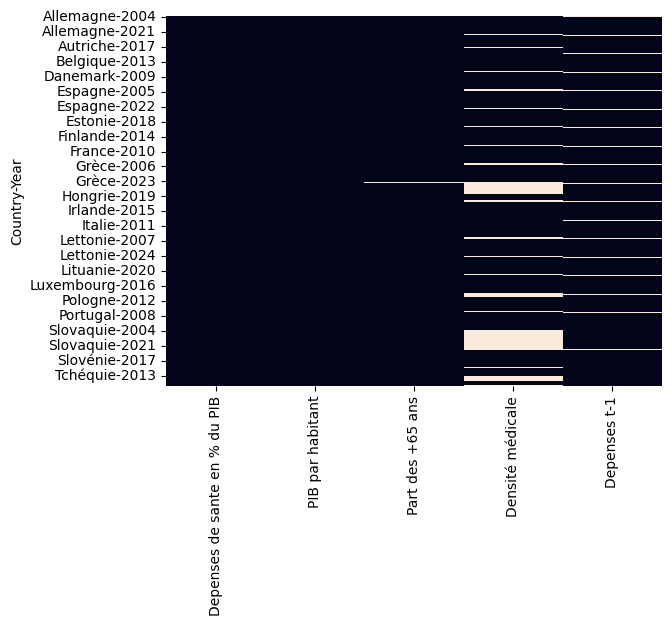

In [8]:
df = panel.copy()
sns.heatmap(df.isna(), cbar=False)
plt.show()

<Axes: >

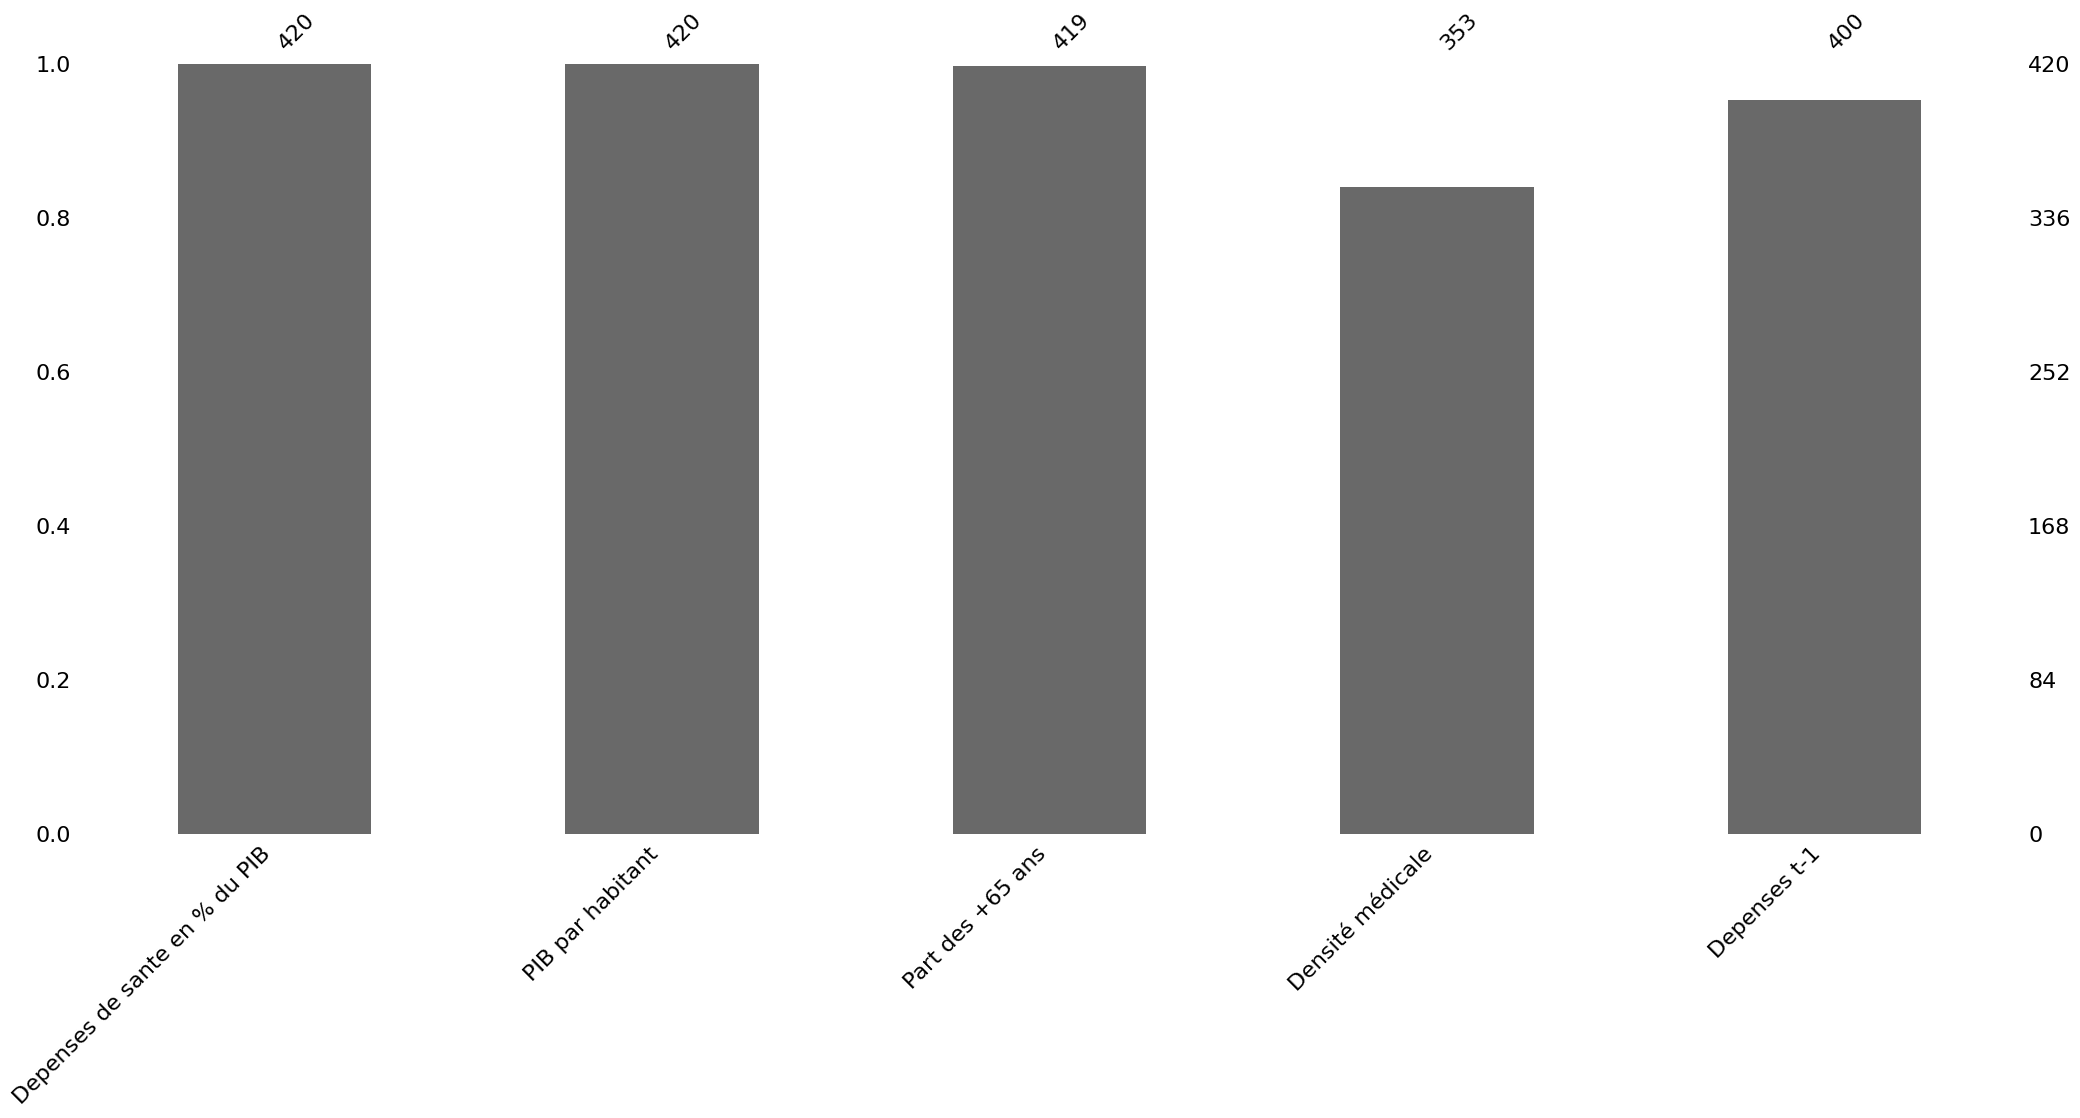

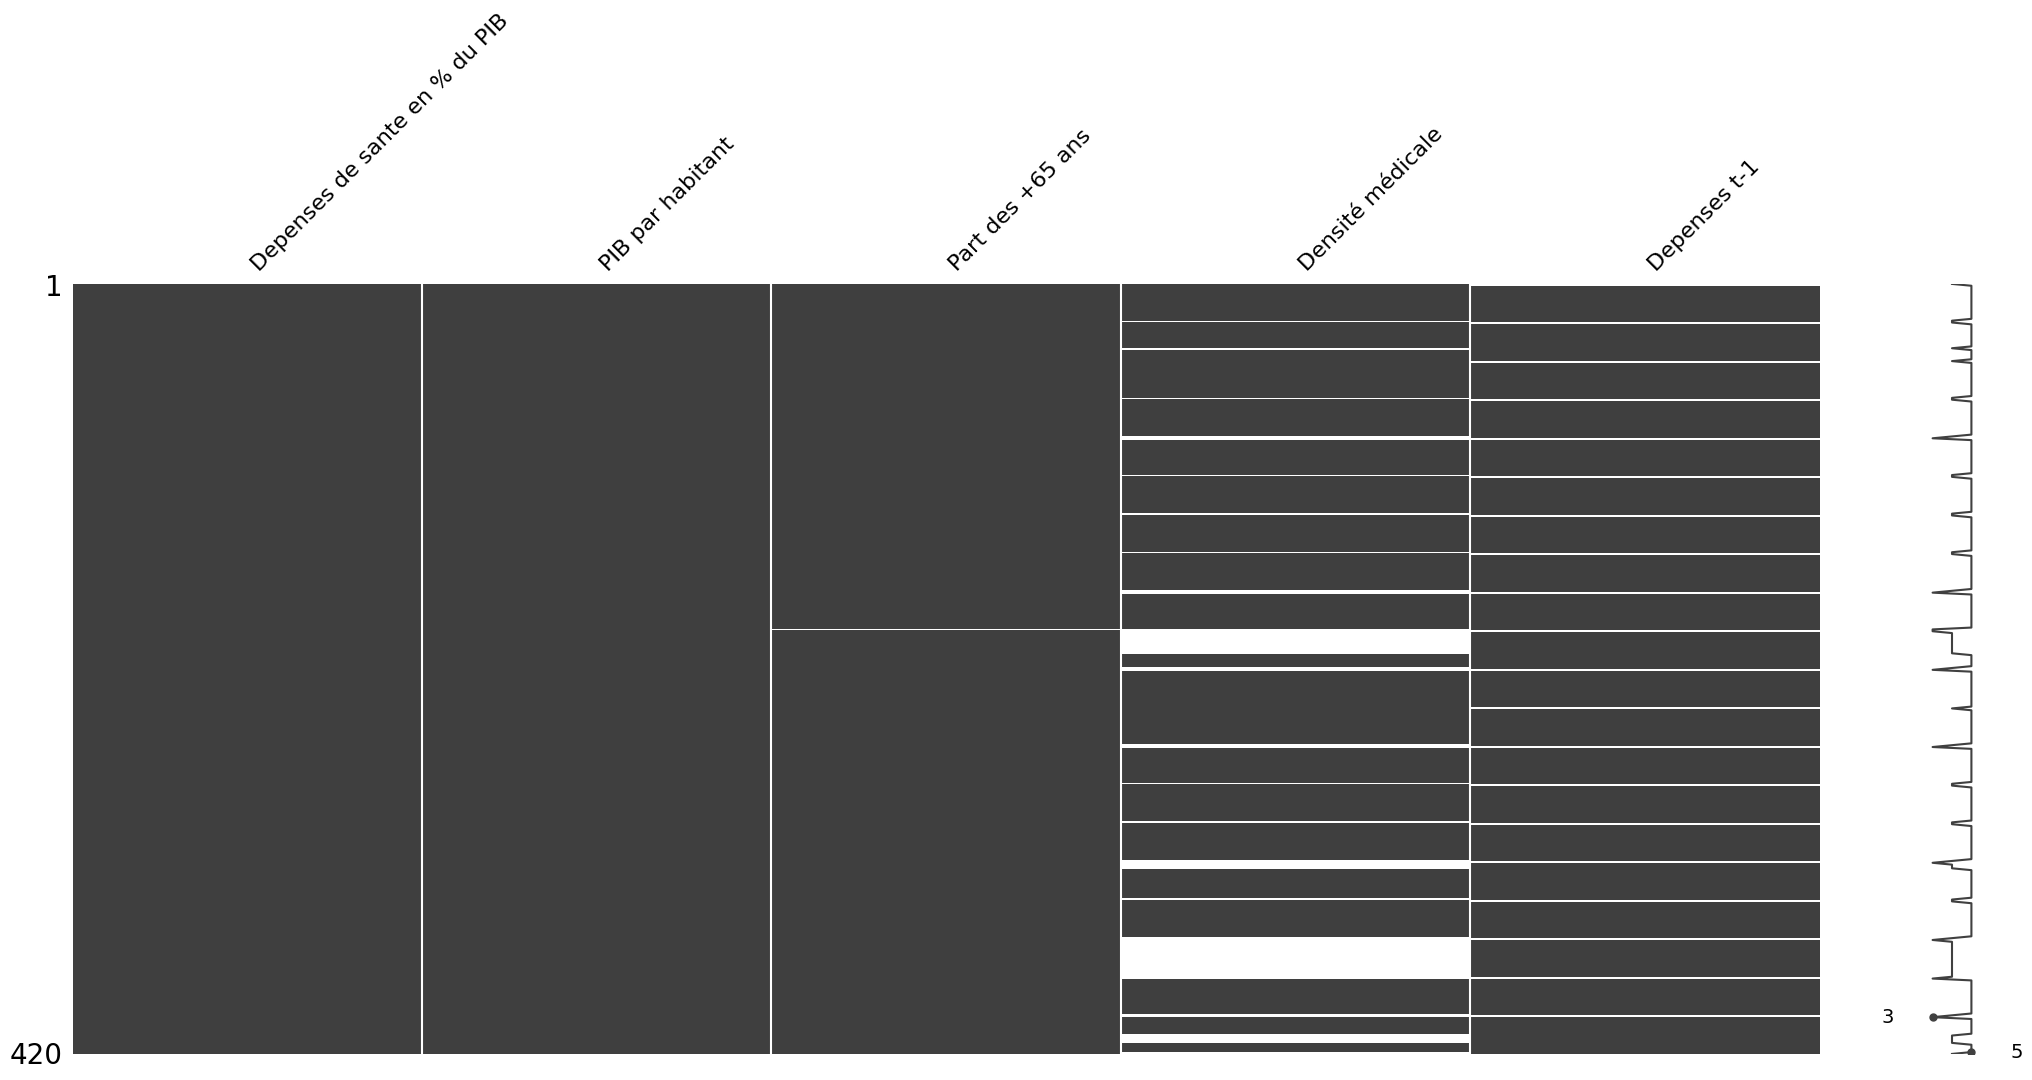

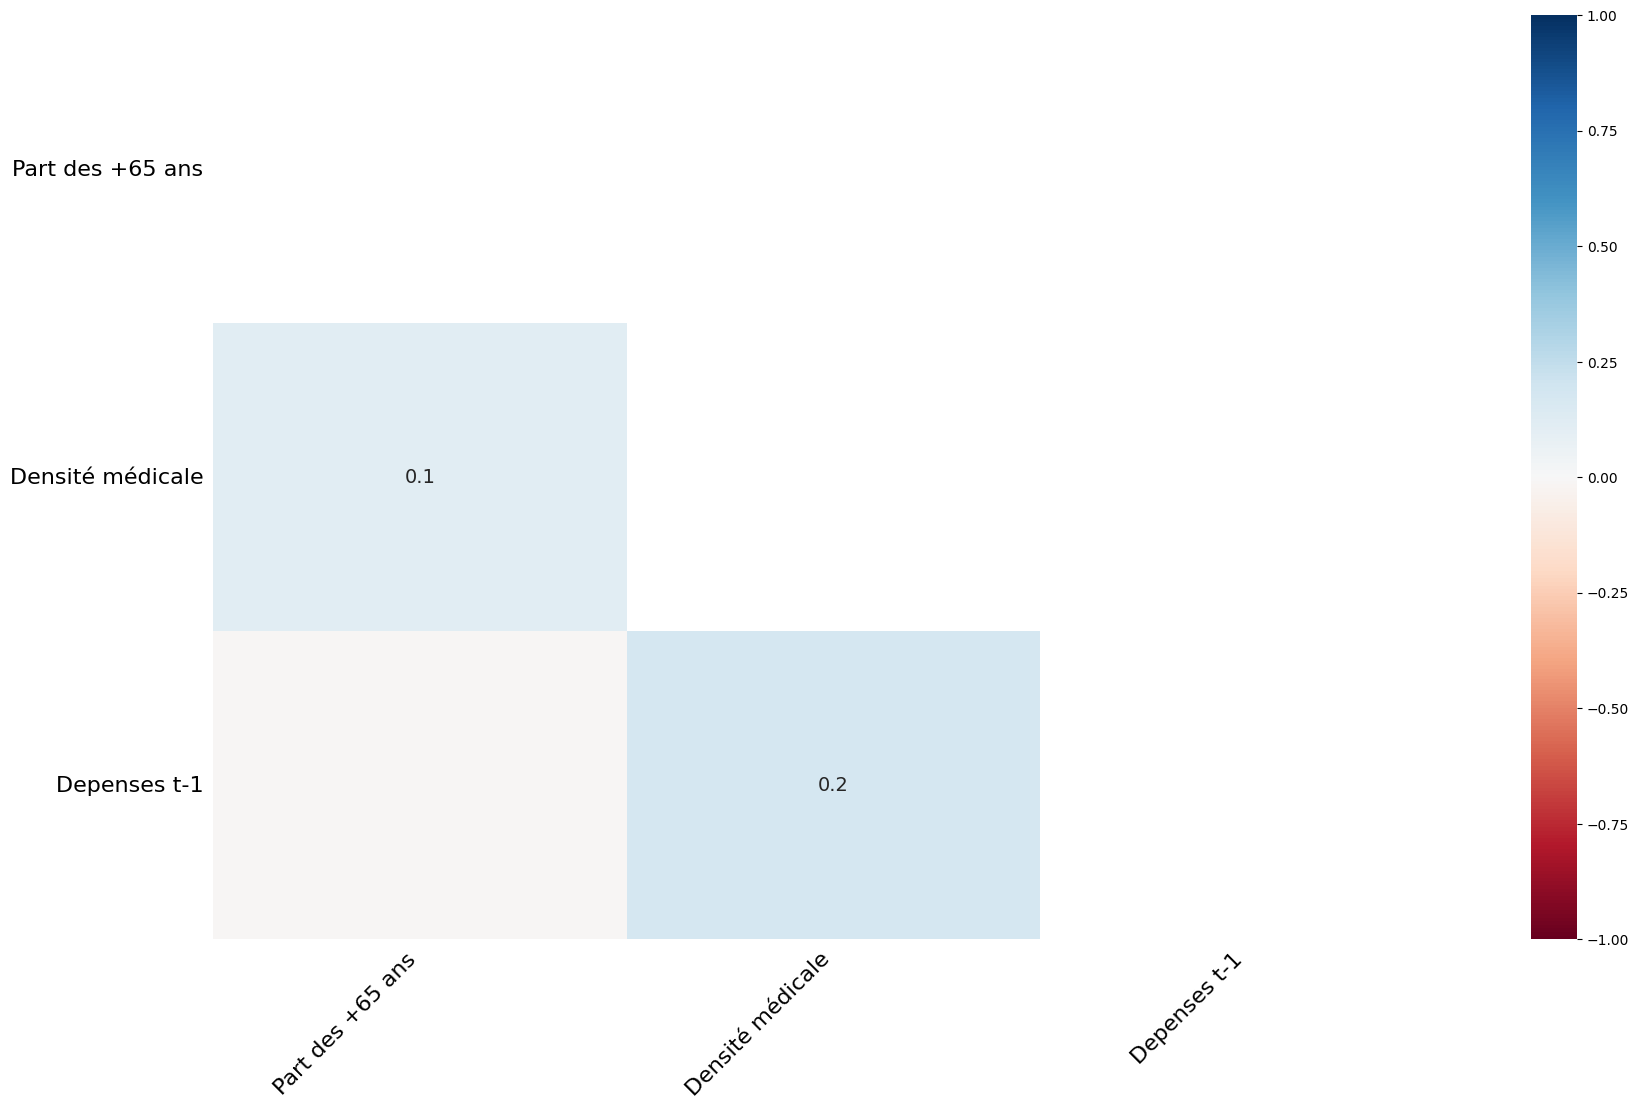

In [9]:
#visualisation des valeurs manquantes

df = panel.copy()
msno.bar(df)
msno.matrix(df)
msno.heatmap(df)

A value near -1 means if one variable appears then the other variable is very likely to be missing.  
A value near 0 means there is no dependence between the occurrence of missing values of two variables.  
A value near 1 means if one variable appears then the other variable is very likely to be present.  

In [10]:
missing_indicator = df.isna().astype(int)
corr = missing_indicator.corr()

print(corr)

                               Depenses de sante en % du PIB  \
Depenses de sante en % du PIB                            NaN   
PIB par habitant                                         NaN   
Part des +65 ans                                         NaN   
Densité médicale                                         NaN   
Depenses t-1                                             NaN   

                               PIB par habitant  Part des +65 ans  \
Depenses de sante en % du PIB               NaN               NaN   
PIB par habitant                            NaN               NaN   
Part des +65 ans                            NaN          1.000000   
Densité médicale                            NaN          0.112135   
Depenses t-1                                NaN         -0.010924   

                               Densité médicale  Depenses t-1  
Depenses de sante en % du PIB               NaN           NaN  
PIB par habitant                            NaN           NaN  
Part des

In [11]:
import statsmodels.stats.missing
from statsmodels.stats.missing import test_missing_complete

test_missing_complete(df)

ModuleNotFoundError: No module named 'statsmodels.stats.missing'

## Données manquantes

Problème des données manquantes pour la densité médicale :  
Tchéquie 2014-2018  
Hongrie 2004-2016  
Pologne 2004-2007  
2004 et 2024 pour la plupart

In [14]:
#gérer les données manquantes
panel_transformed = panel.copy()

for col in panel.columns :
    panel_transformed[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.median()))

In [17]:
panel_transformed
panel_transformed.to_excel("panel_transformed.xlsx", index=False)

# Régression TTD  
On veut vérifier si contrôler par le TTD atténue l'impact du vieillissement sur les dépenses de santé.  
On fait notre régression sur plusieurs tranches d'âge au-dessus de 65 ans. Comme TTD, on utilise l'espérance de vie résiduelle de la tranche d'âge sur laquelle on se place et on remplace

# Régression et GMM